# 📦 Data download and loading

How to get hold of [Eva-data](https://huggingface.co/datasets/yandrewl/Eva-data), download a region,
read what is in the file, look at a patch, and put the patches back together into a whole region.

Each region is one `.npz` file named after its acquisition id, sitting in a folder per cohort:

| key | shape / dtype | meaning |
|---|---|---|
| `mif` | `(n, 224, 224, K)` float16 | multiplexed patches, scaled to `[0, 1]` |
| `he` | `(n, 224, 224, 3)` uint8 | paired H&E, same patches; missing where it was never acquired |
| `coords` | `(n, 2)` int64 | top-left `(y, x)` pixel of each patch in the region |
| `biomarkers` | `(K,)` str | that region's panel, in channel order |

| cohort | regions | patches | K | H&E | size |
|---|---|---|---|---|---|
| `UPMC-HNC` | 327 | 33,123 | 41 | yes | 42.6 GB |
| `Stanford-CRC` | 406 | 13,461 | 40 | no | 14.6 GB |
| `Stanford-HCC` | 35 | 9,017 | 41 | yes | 9.3 GB |
| `DFCI-HNC` | 58 | 2,266 | 40 | no | 2.9 GB |
| `MDACC-HCC` | 30 | 16,116 | 48 | yes | 17.3 GB |

In [1]:
# Run from the repository root so that relative imports and paths resolve.
import os

if os.path.basename(os.getcwd()) == "tutorials":
    os.chdir("..")

## Step 1. Get access and log in

The data is gated and released under CC BY-NC-ND 4.0. Open the
[dataset page](https://huggingface.co/datasets/yandrewl/Eva-data), fill in the access form.

Once you are through, log in on whatever machine does the downloading:

```bash
huggingface-cli login   # token from https://huggingface.co/settings/tokens
```

or from inside a notebook:

```python
from huggingface_hub import notebook_login
notebook_login()
```

## Step 2. Download one region

Grab a single `.npz` first rather than a whole cohort. The one below is a 4032 x 4032 liver core
from `Stanford-HCC` with paired H&E, about 140 MB.

In [2]:
from huggingface_hub import hf_hub_download

REPO_ID = "yandrewl/Eva-data"
COHORT = "Stanford-HCC"
REGION = "NiaRenu2_c004_v002_r001_reg027"

npz_path = hf_hub_download(
    repo_id=REPO_ID,
    filename=f"{COHORT}/{REGION}.npz",
    repo_type="dataset",
)
print(npz_path)

~/.cache/huggingface/hub/datasets--yandrewl--Eva-data/snapshots/46e2909dbbd73b2009d8bf7f9b675d88e2602fe5/Stanford-HCC/NiaRenu2_c004_v002_r001_reg027.npz


Every cohort also carries a `manifest.csv` with its regions, patch counts, file sizes and checksums,
which is the easy way to pick a region before pulling anything big.

In [3]:
import pandas as pd

manifest = pd.read_csv(
    hf_hub_download(repo_id=REPO_ID, filename=f"{COHORT}/manifest.csv", repo_type="dataset")
)
print(f"{len(manifest)} regions in {COHORT}, {manifest.n_patches.sum()} patches in total")
manifest.head()

35 regions in Stanford-HCC, 9017 patches in total


,region,n_patches,bytes,sha256
0,NiaRenu2_c004_v001_r002_reg005,272,806339951,aa34ee8b4f1c4e81d335ed12b8d83100d5d2ae5889b1dc...
1,NiaRenu2_c004_v002_r001_reg001,271,240891218,761ac0c2a22f6038425b296ad8cfc66b8a806655eb68a6...
2,NiaRenu2_c004_v002_r001_reg002,235,153165316,ac0aa8e8901b159535023f86c25b8d2733bb92791ba3d7...
3,NiaRenu2_c004_v002_r001_reg003,243,191590077,236abbb94e2f3dfd3e628ebda5754c6b08db4390faf8fc...
4,NiaRenu2_c004_v002_r001_reg004,289,230610377,f679d4586bb9710938843d133768db66b77b9cb4e39d40...


In [4]:
# To pull an entire cohort instead (see the size column above):
#
# from huggingface_hub import snapshot_download
# snapshot_download(
#     REPO_ID,
#     repo_type="dataset",
#     allow_patterns=f"{COHORT}/*",
#     local_dir="data",
# )

## Step 3. See what is in the file

`np.load` on an `.npz` gives back a lazy archive, so nothing is actually read until you index a key.

In [5]:
import numpy as np

data = np.load(npz_path)

for key in data.files:
    print(f"{key:<12}{str(data[key].shape):<24}{data[key].dtype}")

mif         (294, 224, 224, 41)     float16


he          (294, 224, 224, 3)      uint8
coords      (294, 2)                int64
biomarkers  (41,)                   <U32


In [6]:
mif = data["mif"]                         # (n, 224, 224, K) float16, already scaled to [0, 1]
coords = data["coords"]                   # (n, 2) top-left (y, x) of each patch in the region
biomarkers = data["biomarkers"].tolist()  # (K,) panel, in channel order

# H&E is missing for MIF-only cohorts (Stanford-CRC, DFCI-HNC), so check before using it.
he = data["he"] if "he" in data.files else None

print(f"{len(mif)} patches, {len(biomarkers)} channels, H&E {'present' if he is not None else 'absent'}")
print(biomarkers)

294 patches, 41 channels, H&E present
['DAPI', 'CD31', 'CD117', 'FoxP3', 'CD45', 'CD8', 'CD19', 'Keratin19', 'PD1', 'CD15', 'CD141', 'CD1c', 'CD183', 'CD11b', 'Vimentin', 'HLA-DR', 'CD107a', 'CD163', 'aSMA', 'PDL1', 'CD14', 'Siglec8', 'CD4', 'CD20', 'EpCAM', 'TIM3', 'CD11c', 'S100A4', 'CD56', 'CD45RO', 'Ki67', 'ECad', 'CD206', 'CD3e', 'CD44', 'PanCK', 'Podoplanin', 'CD197', 'CD68', 'BCL2', 'CD45RA']


Two things to fix up before the arrays go anywhere else:

- `mif` is float16 in `[0, 1]`, cast it to float32 for plotting and for the model.
- `he` is uint8 in `[0, 255]`, divide by 255.

## Step 4. Look at one patch

`compose_overlay` paints a few channels into a single RGB image, one color per marker. The channels
are picked out of this region's own panel by name.

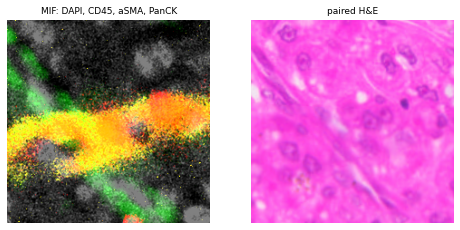

In [7]:
import matplotlib.pyplot as plt

from utils.overlay import compose_overlay

idx = 259
selected = ["DAPI", "CD45", "aSMA", "PanCK"]
colors = ["gray", "red", "green", "yellow"]
channels = [biomarkers.index(m) for m in selected]

overlay = compose_overlay(mif[idx].astype(np.float32), channels=channels, colors=colors)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(overlay)
ax[0].set_title("MIF: " + ", ".join(selected), fontsize=9)
ax[1].imshow(he[idx] / 255.0)
ax[1].set_title("paired H&E", fontsize=9)
for a in ax:
    a.axis("off")

A single channel is just an index into the last axis, again by name.

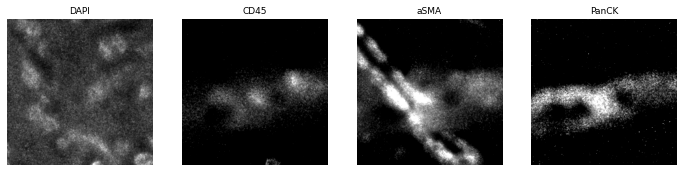

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for a, marker in zip(ax, selected):
    a.imshow(mif[idx, ..., biomarkers.index(marker)].astype(np.float32), cmap="gray")
    a.set_title(marker, fontsize=9)
    a.axis("off")

## Step 5. Stitch the patches back into a region

The patches sit on a regular 224-pixel grid and `coords` holds the top-left corner of each one, so
writing every patch back at its offset gives you the region again. Only tiles with tissue in them
made it into the release, 294 out of the 18 x 18 = 324 here, which is why the corners stay black.

All 41 channels as float32 would be around 2.7 GB for this region, so the canvas below only holds
the channels the figure needs.

In [9]:
h, w = coords.max(0) + 224
print(f"region canvas: {h} x {w} pixels, {len(coords)} patches")

region_mif = np.zeros((h, w, len(channels)), dtype=np.float32)
region_he = np.zeros((h, w, 3), dtype=np.uint8)

for i, (y, x) in enumerate(coords):
    region_mif[y:y + 224, x:x + 224] = mif[i][..., channels].astype(np.float32)
    if he is not None:
        region_he[y:y + 224, x:x + 224] = he[i]

region canvas: 4032 x 4032 pixels, 294 patches


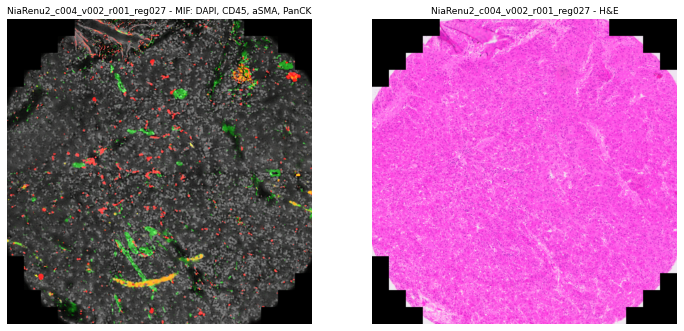

In [10]:
region_overlay = compose_overlay(region_mif, channels=range(len(channels)), colors=colors)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(region_overlay)
ax[0].set_title(f"{REGION} - MIF: " + ", ".join(selected), fontsize=9)
ax[1].imshow(region_he / 255.0)
ax[1].set_title(f"{REGION} - H&E", fontsize=9)
for a in ax:
    a.axis("off")

Same idea for one marker over the whole region, with a single-channel canvas. CD68 picks out the
Kupffer cells scattered through this core:

(-0.5, 4031.5, 4031.5, -0.5)

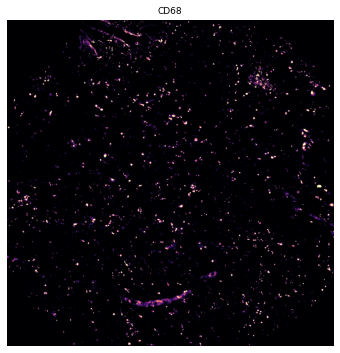

In [11]:
cd68_channel = biomarkers.index("CD68")
region_cd68 = np.zeros((h, w), dtype=np.float32)
for i, (y, x) in enumerate(coords):
    region_cd68[y:y + 224, x:x + 224] = mif[i][..., cd68_channel].astype(np.float32)

plt.figure(figsize=(6, 6))
plt.imshow(region_cd68, cmap="magma", vmax=np.percentile(region_cd68, 99.5))
plt.title("CD68", fontsize=9)
plt.axis("off")

## Step 6. Where to go next

These arrays drop straight into the model. `mif` is already `[B, H, W, C]` once you add a batch
axis, and `biomarkers` is the marker list that goes with it.

```python
import torch
from omegaconf import OmegaConf
from Eva.utils import extract_features, load_from_hf

conf = OmegaConf.load("config.yaml")
device = "cuda" if torch.cuda.is_available() else "cpu"
model = load_from_hf(repo_id="yandrewl/Eva", conf=conf, device=device)

features = extract_features(
    patch=torch.from_numpy(mif[idx].astype(np.float32)).unsqueeze(0),  # [1, 224, 224, K]
    bms=[biomarkers],
    model=model,
    device=device,
    cls=False,
    channel_mode="full",
)
print(features.shape)  # [1, 768]
```

[02_basic.ipynb](02_basic.ipynb) picks up from here with model loading, the GenePT marker embeddings
that feature extraction needs, and MIF + H&E inputs.